In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

warnings.filterwarnings('ignore')

#### Reading data

In [2]:
df = pd.read_csv("features.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print('Shape:', df.shape)
display(df.head())

Shape: (26448, 46)


,date,region_city,alarm_count,alarm_total_duration_min,alarm_all_region,city_address,day_tempmax,day_tempmin,day_temp,day_humidity,...,region_city_bigrams,city_address_unigrams,city_address_bigrams,day_conditions_unigrams,day_conditions_bigrams,isw_text_unigrams,isw_text_bigrams,total_regions_with_alarm_day,alarms_yesterday,duration_7d_avg
0,2022-02-24,Івано-Франківська обл.,0.0,0.0,0.0,"Ivano-Frankivsk,Ukraine",5.7,0.1,2.7,75.2,...,[],['ivanofrankivskukraine'],[],"['snow', 'rain', 'partially', 'cloudy']","['snow rain', 'rain partially', 'partially clo...","['russian', 'offensive', 'campaign', 'assessme...","['russian offensive', 'offensive campaign', 'c...",4.0,0.0,0.0
1,2022-02-24,Чернівецька обл.,0.0,0.0,0.0,"Chernivtsi,Ukraine",6.5,-0.2,3.4,74.9,...,[],['chernivtsiukraine'],[],"['snow', 'partially', 'cloudy']","['snow partially', 'partially cloudy']","['russian', 'offensive', 'campaign', 'assessme...","['russian offensive', 'offensive campaign', 'c...",4.0,0.0,0.0
2,2022-02-24,Вінницька обл.,1.0,30.0,1.0,"Vinnytsia,Ukraine",5.0,0.7,2.8,80.5,...,[],['vinnytsiaukraine'],[],"['snow', 'rain', 'partially', 'cloudy']","['snow rain', 'rain partially', 'partially clo...","['russian', 'offensive', 'campaign', 'assessme...","['russian offensive', 'offensive campaign', 'c...",4.0,0.0,30.0
3,2022-02-24,Черкаська обл.,0.0,0.0,0.0,"Cherkasy,Ukraine",4.9,-0.1,1.9,83.4,...,[],['cherkasyukraine'],[],"['partially', 'cloudy']",['partially cloudy'],"['russian', 'offensive', 'campaign', 'assessme...","['russian offensive', 'offensive campaign', 'c...",4.0,0.0,0.0
4,2022-02-24,Дніпропетровська обл.,0.0,0.0,0.0,"Dnipro,Ukraine",8.0,-2.0,3.1,70.6,...,[],['dniproukraine'],[],"['partially', 'cloudy']",['partially cloudy'],"['russian', 'offensive', 'campaign', 'assessme...","['russian offensive', 'offensive campaign', 'c...",4.0,0.0,0.0


#### Define X, y

In [3]:
TARGET = 'alarm_all_region'

LEAKAGE_COLS = [
    'alarm_count',
    'alarm_total_duration_min',
    'regions_with_alarm_today',
    'total_regions_with_alarm_day',
    'target_alarm_next_day',
]

X = (df
     .select_dtypes(include=[np.number])
     .drop(columns=[TARGET] + LEAKAGE_COLS, errors='ignore')
     .fillna(0))

y = df[TARGET].astype(int)

feature_cols = X.columns.tolist()
print(f'Features ({len(feature_cols)}): {feature_cols}')
print(f'\nTarget розподіл:\n{y.value_counts()}')

Features (26): ['day_tempmax', 'day_tempmin', 'day_temp', 'day_humidity', 'day_precip', 'day_precipprob', 'day_snow', 'day_snowdepth', 'day_windgust', 'day_windspeed', 'day_winddir', 'day_pressure', 'day_cloudcover', 'day_visibility', 'day_solarradiation', 'day_uvindex', 'alarm_lag1', 'alarm_lag2', 'alarm_lag7', 'alarm_roll7_mean', 'duration_lag1', 'day_of_week', 'month', 'region_encoded', 'alarms_yesterday', 'duration_7d_avg']

Target розподіл:
alarm_all_region
1    18073
0     8375
Name: count, dtype: int64


#### TimeSeriesSplit

In [10]:
rows_per_day = df.groupby('date').size().mean()
test_size = int(rows_per_day * 30)

tscv = TimeSeriesSplit(
    n_splits=5,
    test_size=test_size,
    gap=0
)

#### Hyperparameter Tuning

In [5]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=2000, random_state=42))
])

param_grid = {
    'lr__C': [0.001, 0.01, 0.1, 1.0, 10.0],  
    'lr__penalty': ['l1', 'l2'],             
    'lr__solver': ['liblinear', 'saga'],     
    'lr__class_weight': [None, 'balanced']  
}

tscv_tune = TimeSeriesSplit(n_splits=3, test_size=test_size)

search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=tscv_tune,
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search.fit(X.values, y.values)

print('Найкращі параметри:')
print(search.best_params_)
print(f'\nНайкращий F1 (cv): {search.best_score_:.3f}')

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Найкращі параметри:
{'lr__solver': 'saga', 'lr__penalty': 'l1', 'lr__class_weight': None, 'lr__C': 0.01}

Найкращий F1 (cv): 0.799


#### Fold Evaluation

In [11]:
best_pipeline = search.best_estimator_

acc_scores = []
f1_scores  = []
y_test_last = None
y_pred_last = None

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train = X.iloc[train_idx].values
    X_test  = X.iloc[test_idx].values
    y_train = y.iloc[train_idx].values
    y_test  = y.iloc[test_idx].values

    best_pipeline.fit(X_train, y_train)
    y_pred = best_pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    acc_scores.append(acc)
    f1_scores.append(f1)

    if fold == 4:
        y_test_last = y_test
        y_pred_last = y_pred

    print(f'Fold {fold+1} │ train={len(train_idx):,}  test={len(test_idx):,} │ acc={acc:.3f}  f1={f1:.3f}')

print()
print(f'Mean  │ acc={np.mean(acc_scores):.3f} ±{np.std(acc_scores):.3f}  │  f1={np.mean(f1_scores):.3f} ±{np.std(f1_scores):.3f}')

Fold 1 │ train=22,848  test=720 │ acc=0.819  f1=0.815
Fold 2 │ train=23,568  test=720 │ acc=0.815  f1=0.812
Fold 3 │ train=24,288  test=720 │ acc=0.768  f1=0.760
Fold 4 │ train=25,008  test=720 │ acc=0.810  f1=0.810
Fold 5 │ train=25,728  test=720 │ acc=0.828  f1=0.826

Mean  │ acc=0.808 ±0.021  │  f1=0.805 ±0.023


#### Confusion Matrix

In [7]:
print('Confusion matrix (fold 5):')
print(confusion_matrix(y_test_last, y_pred_last))
print()
print(classification_report(y_test_last, y_pred_last, zero_division=0))

Confusion matrix (fold 5):
[[152  71]
 [ 53 444]]

              precision    recall  f1-score   support

           0       0.74      0.68      0.71       223
           1       0.86      0.89      0.88       497

    accuracy                           0.83       720
   macro avg       0.80      0.79      0.79       720
weighted avg       0.82      0.83      0.83       720



#### Top 20 features

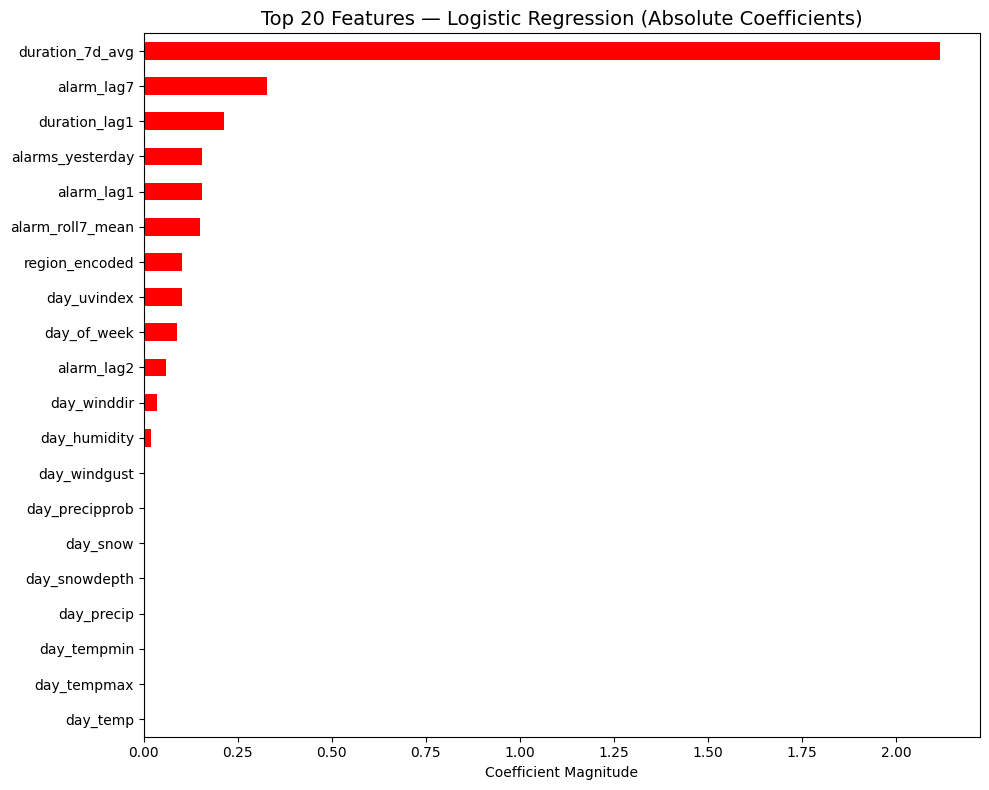

In [9]:
lr_model = best_pipeline.named_steps['lr']

importances = pd.Series(np.abs(lr_model.coef_[0]), index=feature_cols)

signs = np.sign(lr_model.coef_[0])
top20_indices = importances.nlargest(20).index

fig, ax = plt.subplots(figsize=(10, 8))


importances[top20_indices].sort_values().plot(kind='barh', ax=ax, color='red')
ax.set_title('Top 20 Features — Logistic Regression (Absolute Coefficients)', fontsize=14)
ax.set_xlabel('Coefficient Magnitude')
plt.tight_layout()
plt.show()